In [75]:
# TASK- 3 

In [146]:
import torch
import torchvision
from torchvision import transforms, datasets

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm

In [147]:
#loading Data 
file_loc = "C:\\Users\\tauhe\Downloads\\data set\\Ieuan Griffiths - MS4S16 - Coursework Dataset"

load_train = f'{file_loc}\\train_data.pt'
load_train_labels = f'{file_loc}\\train_labels.pt'

load_test = f'{file_loc}\\test_data.pt'
load_test_labbels = f'{file_loc}\\test_labels.pt'


In [ ]:
train_images = torch.load(load_train)
test_images = torch.load(load_test)
train_labels = torch.load(load_train_labels).to(torch.long)
test_labels = torch.load(load_test_labels).to(torch.long)

In [163]:
import matplotlib.pyplot as plt

The Corrosponding Label is: 3


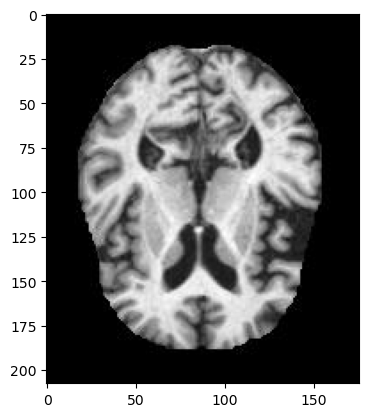

In [164]:
sample_num = 100
print(f'The Corrosponding Label is: {train_labels[sample_num]}')
plt.imshow(train_images[sample_num][0], cmap='gray')
plt.show()

# Creating a Basic Convolutional neural network

In [177]:
class Conv_NN(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        
        # Creating Convolutional Layers & Max Pooling Layer Defined:
        self.conv1 = nn.Conv2d(in_channels = n_channels, out_channels = 8, kernel_size = (3,3) )
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16,  kernel_size = (3,3))
        self.pool = nn.MaxPool2d((2,2))
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x)) # adding Relu activation function
        x = self.pool(x)
        print(f"Shape of Data before Flattening: {x.shape}")

        return x


In [178]:
net  = Conv_NN(n_channels = 3) #no of channels 3 as we have coloured images

In [179]:
n_samples = 10
test_output = net.forward(train_images[0:n_samples]) 

Shape of Data before Flattening: torch.Size([10, 16, 50, 42])


In [186]:
n_dimensions = 1
myfunc = nn.Flatten(n_dimensions)

test_output2 = myfunc(test_output)
print(f"The Shape after using the Flatten Function is: {test_output2.shape}")

The Shape after using the Flatten Function is: torch.Size([10, 33600])


In [187]:
net  = Conv_NN(n_channels = 3)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

In [188]:
class Conv_NN(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        
        # Convolutional Layers & Max Pooling Layer Defined:
        self.conv1 = nn.Conv2d(in_channels = n_channels, out_channels = 8, kernel_size = (3,3) )
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16,  kernel_size = (3,3))
        self.pool = nn.MaxPool2d((2,2))
        
        self.flatten = nn.Flatten(1)
        
        # Linear Layers:
        self.fc1 = nn.Linear(16*50*42, 128)
        self.fc2 = nn.Linear(128, 4)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = self.flatten(x)

        x = F.relu(self.fc1(x))
        x = F.log_softmax(self.fc2(x), dim=1)

        return x

In [189]:
epochs = 10
BATCH_SIZE = 100

for epoch in range(epochs):
    for i in tqdm(range(0, len(train_images), BATCH_SIZE)):
        # Batch Our Data:
        batch_data = train_images[i:i + BATCH_SIZE]
        batch_labels = train_labels[i:i + BATCH_SIZE]
        
        # Convert target labels to the appropriate format
        batch_labels = torch.LongTensor(batch_labels).squeeze()
        
        # Calculate Output:
        optimizer.zero_grad()  
        output = net(batch_data)  
        
        # Calculate & Update Gradients:
        loss = loss_function(output, batch_labels) 
        loss.backward()  
        optimizer.step()  
    
    # Print loss and epoch number
    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")


100%|██████████| 52/52 [02:58<00:00,  3.43s/it]


Epoch 1, Loss: 0.9447314143180847


100%|██████████| 52/52 [00:59<00:00,  1.14s/it]


Epoch 2, Loss: 0.9394309520721436


100%|██████████| 52/52 [00:58<00:00,  1.13s/it]


...

Epoch 8, Loss: 0.8250007629394531


100%|██████████| 52/52 [00:59<00:00,  1.14s/it]


Epoch 9, Loss: 0.8208900690078735


100%|██████████| 52/52 [00:57<00:00,  1.10s/it]

Epoch 10, Loss: 0.814164400100708


In [190]:
with torch.no_grad():
    predicted = net.forward(test_images)
    print(predicted[0:2], predicted[0:2].shape)
    
    predicted_classes = torch.argmax(predicted, dim = 1)
    print(predicted_classes[0:5])
    print(test_labels[0:5])
    
correct = 0
total = 0
for i in range(len(predicted_classes)):

    if predicted_classes[i] == test_labels[i]:
        correct += 1
    total += 1
print("Accuracy: ", round(correct/total, 3))

tensor([[-4.4977, -5.0306, -0.2957, -1.4343],
        [-4.4977, -4.9567, -0.3205, -1.3624]]) torch.Size([2, 4])
tensor([2, 2, 2, 2, 2])
tensor([3, 2, 2, 0, 0])
Accuracy:  0.515


In [193]:
from sklearn.metrics import confusion_matrix

In [194]:
cf_mat = confusion_matrix(test_labels, predicted_classes)
cf_mat  #creating a confusion matrix

array([[  0,   0, 162,  17],
       [  0,   0,  12,   0],
       [  0,   0, 637,   3],
       [  0,   0, 426,  22]], dtype=int64)

From the basic model we got an accuracy of 51

# Improved CNN 

In [199]:
class Improved_CNN(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        
        # Convolutional Layers & Max Pooling Layer Defined:
        self.conv1 = nn.Conv2d(in_channels=n_channels, out_channels=8, kernel_size=(5, 5))
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(5, 5))
        self.pool = nn.MaxPool2d((2, 2))
        
        # Flatten Data:
        self.flatten = nn.Flatten(1)
        
        # Linear Layers:
        self.fc1 = nn.Linear(16*49*41, 128)

        self.fc2 = nn.Linear(128, 4)
        
        # Batch Normalization Layers:
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(4)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = self.flatten(x)
 
        x = F.relu(self.bn1(self.fc1(x))) # Apply batch normalization after the first linear layer
        x = F.log_softmax(self.bn2(self.fc2(x)), dim=1)  # Apply batch normalization after the second linear layer

        return x

In this improved model we add batch normalization for each layer to get better results

In [200]:
net  = Improved_CNN(n_channels = 3)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

In [202]:
epochs = 15
BATCH_SIZE = 75
for epoch in range (epochs):
    for i in tqdm(range(0,len(train_images), BATCH_SIZE)):
        
        batch_data = train_images[i:i+BATCH_SIZE]
        batch_labels = train_labels[i:i+BATCH_SIZE]
        # Calculate Output:
        net.zero_grad()  
        output = net(batch_data)  
        # Updateing the  Gradients:
        loss = loss_function(output, batch_labels) 
        loss.backward()  
        optimizer.step()  
    print(loss)

100%|██████████| 69/69 [01:17<00:00,  1.13s/it]


tensor(0.6741, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:19<00:00,  1.15s/it]


tensor(0.4571, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:23<00:00,  1.21s/it]


...

tensor(0.1561, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:14<00:00,  1.08s/it]


tensor(0.1478, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:17<00:00,  1.12s/it]

tensor(0.1405, grad_fn=<NllLossBackward0>)


In [197]:
net  = Improved_CNN(n_channels = 3)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

In [203]:
with torch.no_grad():
    predicted = net.forward(test_images)
    print(predicted[0:2], predicted[0:2].shape)
    
    predicted_classes = torch.argmax(predicted, dim = 1)
    print(predicted_classes[0:5])
    print(test_labels[0:5])
    
correct = 0
total = 0
for i in range(len(predicted_classes)):

    if predicted_classes[i] == test_labels[i]:
        correct += 1
    total += 1
print("Accuracy: ", round(correct/total, 3))

tensor([[-2.0541, -0.9332, -0.9239, -2.5070],
        [-5.5496, -3.9898, -0.0406, -4.0542]]) torch.Size([2, 4])
tensor([2, 2, 3, 0, 2])
tensor([3, 2, 2, 0, 0])
Accuracy:  0.658


In [204]:
cf_mat = confusion_matrix(test_labels, predicted_classes)
cf_mat

array([[ 85,   1,  50,  43],
       [  1,   6,   3,   2],
       [ 63,   5, 482,  90],
       [ 44,   5, 130, 269]], dtype=int64)

# Learning rate of 0.00000001 vs a Learning rate of 10

In [207]:
net  = Improved_CNN(n_channels = 3)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.00000001)

In [208]:
epochs = 15
BATCH_SIZE = 75
for epoch in range (epochs):
    for i in tqdm(range(0,len(train_images), BATCH_SIZE)):
        # Batch Our Data:
        batch_data = train_images[i:i+BATCH_SIZE]
        batch_labels = train_labels[i:i+BATCH_SIZE]
        net.zero_grad()  
        output = net(batch_data)  
        loss = loss_function(output, batch_labels) 
        loss.backward()  
        optimizer.step()  
    print(loss)


100%|██████████| 69/69 [01:17<00:00,  1.13s/it]


tensor(1.6778, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:14<00:00,  1.08s/it]


tensor(1.6776, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:13<00:00,  1.07s/it]


...

tensor(1.6755, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:17<00:00,  1.12s/it]


tensor(1.6753, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:16<00:00,  1.11s/it]

tensor(1.6751, grad_fn=<NllLossBackward0>)


In [209]:
with torch.no_grad():
    predicted = net.forward(test_images.to('cpu'))
    print(predicted[0:2], predicted[0:2].shape)
    
    
    predicted_classes = torch.argmax(predicted, dim = 1)
    print(predicted_classes[0:5])
    print(test_labels[0:5])
    
    correct = 0
total = 0
for i in range(len(predicted_classes)):

    if predicted_classes[i] == test_labels[i]:
        correct += 1
    total += 1
print("Accuracy: ", round(correct/total, 3))

tensor([[-1.3269, -1.6505, -1.6390, -1.0539],
        [-1.6723, -0.6470, -1.6780, -2.2842]]) torch.Size([2, 4])
tensor([3, 1, 3, 0, 2])
tensor([3, 2, 2, 0, 0])
Accuracy:  0.298


With Learning rate 10

In [210]:
net  = Improved_CNN(n_channels = 3)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=10)


In [211]:
epochs = 15
BATCH_SIZE = 75
for epoch in range (epochs):
    for i in tqdm(range(0,len(train_images), BATCH_SIZE)):
        # Batch Our Data:
        batch_data = train_images[i:i+BATCH_SIZE]
        batch_labels = train_labels[i:i+BATCH_SIZE]
        # Calculate Output:
        net.zero_grad()  
        output = net(batch_data)  
        # CAlculate & Update Gradients:
        loss = loss_function(output, batch_labels) 
        loss.backward()  
        optimizer.step()  
    print(loss)


100%|██████████| 69/69 [01:42<00:00,  1.48s/it]


tensor(1.6426, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:13<00:00,  1.06s/it]


tensor(1.4319, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:20<00:00,  1.17s/it]


...

tensor(0.0046, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:10<00:00,  1.02s/it]


tensor(0.0018, grad_fn=<NllLossBackward0>)


100%|██████████| 69/69 [01:11<00:00,  1.03s/it]

tensor(0.0012, grad_fn=<NllLossBackward0>)


In [212]:
with torch.no_grad():
    predicted = net.forward(test_images.to('cpu'))
    print(predicted[0:2], predicted[0:2].shape)
    
    
    predicted_classes = torch.argmax(predicted, dim = 1)
    print(predicted_classes[0:5])
    print(test_labels[0:5])

correct = 0
total = 0
for i in range(len(predicted_classes)):

    if predicted_classes[i] == test_labels[i]:
        correct += 1
    total += 1
    
print("Accuracy: ", round(correct/total, 3))

tensor([[-10.9750, -11.7511,  -0.9597,  -0.4830],
        [ -8.5495, -11.4720,  -0.3091,  -1.3254]]) torch.Size([2, 4])
tensor([3, 2, 3, 0, 2])
tensor([3, 2, 2, 0, 0])
Accuracy:  0.59


When we tested with different learning rates for our Convolutional Neural Network (CNN),
we noticed some interesting outcomes. 
When we set an extremely low learning rate of 0.00000001, the model struggled to learn well, and its accuracy was vwery low 29.8%. 
On the other hand, cranking up the learning rate to 10 resulted accuracy (59%).
This high rate caused the model to take giant steps during training, making it hard to find the right path to a good solution.
However, our initial setup with a learning rate of 0.01, 15 epochs, and a batch size of 75 performed best,
reaching an accuracy of 65%. 
It's clear that finding the right learning rate is crucial for getting the best out of our model.

Higher Batch Sizes:
Advantages:

Improved efficiency due to faster training times.
Enhanced stability in training .
Regularization benefits by averaging gradients over more samples.
Disadvantages:

Increased memory requirements.
Limiting model size on certain hardware.
Potential loss of stochasticity, hindering generalization to unseen data.

Lower Batch Sizes:
Advantages:

Improved generalization to unseen data by introducing more randomness.
Memory efficiency, enabling training of larger models on limited hardware.
Enhanced exploratory learning, allowing the model to escape local minima.

Disadvantages:

Slower convergence due to noisy updates and less stable gradients.
Increased variance in gradient estimates, leading to less consistent updates.
Computational inefficiency on hardware optimized for larger batch sizes.